# Get the data needed for DeepSTARR with RNA augmentation

To do: </br>
- figure out way to get metacells

In [1]:
here::i_am("atac/archR/DeepSTARR/trial1_Export_data.ipynb")

#####################
## Define settings ##
#####################

source(here::here("settings.R"))
source(here::here("utils.R"))
suppressPackageStartupMessages({
    library(BSgenome.Mmusculus.UCSC.mm10)
    library(parallel)
})

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code



In [2]:
# Options
args = list()
args$pseudobulk_matrix = file.path(io$basedir, 'results/atac/archR/metacells/all_cells/PeakMatrix/PeakMatrix_summarized_experiment_metacells.rds')
args$pseudobulk_tfs = file.path(io$basedir, 'results/rna/metacells/all_cells/SingleCellExperiment_TFs_metacells.rds')

args$celltypes = c("Epiblast",
                    "Primitive_Streak" ,
                    "Nascent_mesoderm",
                    "ExE_mesoderm",
                    "Mixed_mesoderm",
                    "Allantois",
                    "Mesenchyme",
                    "Haematoendothelial_progenitors",
                    "Endothelium",
                    "Blood_progenitors_1",
                    "Blood_progenitors_2",
                    "Erythroid1",
                    "Erythroid2",
                    "Erythroid3")
args$markers = file.path(io$basedir, 'results/atac/archR/differential/pseudobulk/celltype/PeakMatrix/parsed/markers_filt.txt.gz')
args$outdir = file.path(io$basedir, 'results/atac/archR/DeepSTARR/atac_rna_test')
dir.create(args$outdir, recursive=T, showWarnings=F)

set.seed(1234)

In [3]:
# Load files
Peakmatrix = readRDS(args$pseudobulk_matrix)
tfmatrix = readRDS(args$pseudobulk_tfs)

In [26]:
tfmatrix
Peakmatrix

class: SingleCellExperiment 
dim: 800 2975 
metadata(2): agg_pars n_cells
assays(2): counts logcounts
rownames(800): FOXD1 IRF2 ... FOXM1 SMAD9
rowData names(0):
colnames(2975): E7.5_rep1#AAACCAACATAATCGT-1
  E7.5_rep1#AAACCGAAGAGGGACT-1 ... E8.75_rep2#TTTGGCTGTACTTCAC-1
  E8.75_rep2#TTTGTCCCATTGCGGT-1
colData names(7): sample stage ... ncells nFeature_RNA
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

class: SummarizedExperiment 
dim: 192251 2401 
metadata(0):
assays(1): PeakMatrix
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(4): seqnames idx start end
colnames(2401): E7.5_rep1#AAACGTACAAACCTTG-1
  E7.5_rep1#AACATCATCCAATTAG-1 ... E8.75_rep2#TTTGGCTGTACTTCAC-1
  E8.75_rep2#TTTGGCTGTTAGTGAT-1
colData names(27): TSSEnrichment ReadsInTSS ... FRIP nCells

In [31]:
tfmatrix_filt = tfmatrix[,tfmatrix$celltype %in% args$celltypes]
keep = intersect(colnames(tfmatrix_filt), colnames(Peakmatrix))
tfmatrix_filt = tfmatrix_filt[,keep]
tfmatrix_filt

class: SingleCellExperiment 
dim: 800 243 
metadata(2): agg_pars n_cells
assays(2): counts logcounts
rownames(800): FOXD1 IRF2 ... FOXM1 SMAD9
rowData names(0):
colnames(243): E7.5_rep1#AAACGTACAAACCTTG-1
  E7.5_rep1#AAGCCTGTCATAAGCC-1 ... E8.75_rep2#TACTGGCCAGGATAAC-1
  E8.75_rep2#TCAACAATCGATATTG-1
colData names(7): sample stage ... ncells nFeature_RNA
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [34]:
Peakmatrix_filt = Peakmatrix[,match(colnames(tfmatrix_filt), colnames(Peakmatrix))]
Peakmatrix_filt

class: SummarizedExperiment 
dim: 192251 243 
metadata(0):
assays(1): PeakMatrix
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(4): seqnames idx start end
colnames(243): E7.5_rep1#AAACGTACAAACCTTG-1
  E7.5_rep1#AAGCCTGTCATAAGCC-1 ... E8.75_rep2#TACTGGCCAGGATAAC-1
  E8.75_rep2#TCAACAATCGATATTG-1
colData names(27): TSSEnrichment ReadsInTSS ... FRIP nCells

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


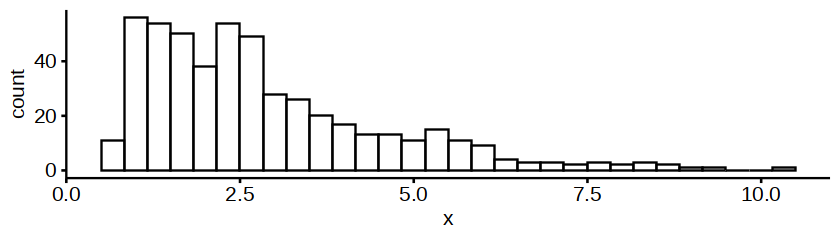

In [35]:
# Take subset of TFs, top 200 with highest Vars
max_tf = rowVars(logcounts(tfmatrix_filt))
names(max_tf) = rownames(tfmatrix_filt)
options(repr.plot.height=2)
keep_tfs = head(names(max_tf[order(-max_tf)]), 500)
tfmatrix_filt = tfmatrix_filt[keep_tfs,]
gghistogram(rowVars(logcounts(tfmatrix_filt)))

In [36]:
# Take random of peaks
Peakmatrix_filt = Peakmatrix_filt[sample(nrow(Peakmatrix_filt), 50000)]

In [37]:
# Split data in train, val, and test sets
# Before did it with the sample function, but this results in different peaks every time
# all_peaks = rownames(Peakmatrix_filt)
# paste0('total peaks: ', length(all_peaks))
# tot_peaks = length(all_peaks)
# val_peaks = sample(all_peaks, tot_peaks/12)
# paste0('peaks in val set: ', length(val_peaks))
# train_peaks = all_peaks[!all_peaks%in%val_peaks]
# paste0('peaks without validation set: ', length(train_peaks))
# test_peaks = sample(train_peaks, tot_peaks/12)
# paste0('peaks in test set: ', length(test_peaks))
# train_peaks = train_peaks[!train_peaks%in%test_peaks]
# paste0('peaks without validation & test set: ', length(train_peaks))

# Train and validation are around 1/10th of train set

all_peaks = rownames(Peakmatrix_filt)
paste0('total peaks: ', length(all_peaks))
tot_peaks = length(all_peaks)
val_test = tot_peaks/12
val_peaks = all_peaks[1:val_test]
paste0('peaks in val set: ', length(val_peaks))
train_peaks = all_peaks[!all_peaks%in%val_peaks]
paste0('peaks without validation set: ', length(train_peaks))
test_peaks = all_peaks[val_test+1:val_test*2]
paste0('peaks in test set: ', length(test_peaks))
train_peaks = train_peaks[!train_peaks%in%test_peaks]
paste0('peaks without validation & test set: ', length(train_peaks))

[1] "total peaks: 50000"

[1] "peaks in val set: 4166"

[1] "peaks without validation set: 45834"

[1] "peaks in test set: 4166"

[1] "peaks without validation & test set: 41668"

### Define functions

In [38]:
# transform peaks to 249 bp flanking centre
# Little bit different than DeepSTARR paper, where they also take regions flanking the centre, but would need to recalculate the accessibility of the new bins
parse_peaks = function(peaks){
    data.table(peak=peaks,
               chr=strsplit(peaks, ':') %>% map_chr(1),
               start=as.numeric(strsplit(strsplit(peaks, ':') %>% map_chr(2), '-') %>% map_chr(1)),
               end=as.numeric(strsplit(strsplit(peaks, ':') %>% map_chr(2), '-') %>% map_chr(2))) %>%
    .[,centre:=round((start+end)/2, 0)] %>% # Get centre of peak and round in case original peak width was an odd number
    .[,`:=`(start=NULL,end=NULL)] %>%
    .[,`:=`(start = centre - 124,
            end = centre + 124)] %>%
    .[,new_peak:=paste0(chr, ':', start, '-', end)]
}

# prepare fasta file
get_fa = function(x, peakset=train_peaks){ # x=row
    # positive strand
    pos_peak = paste0('>', peakset[x,new_peak], '_+')
    pos_fa = paste(as.character(as.vector(getSeq(Mmusculus, peakset[x,chr],
                                         start=peakset[x,start], end=peakset[x,end]))), collapse="")
    # negative strand
    neg_peak = paste0('>', peakset[x,new_peak], '_-')
    neg_fa = paste(as.character(as.vector(reverseComplement(DNAString(pos_fa)))), collapse="")
    
    # return
    tmp = c(pos_peak, pos_fa, neg_peak, neg_fa)
    return(tmp)
}

# prepare fasta file single_stranded
get_fa_ss = function(x, peakset=train_peaks){ # x=row
    # positive strand
    pos_peak = paste0('>', peakset[x,new_peak], '_+')
    pos_fa = paste(as.character(as.vector(getSeq(Mmusculus, peakset[x,chr],
                                         start=peakset[x,start], end=peakset[x,end]))), collapse="")
    # return
    tmp = c(pos_peak, pos_fa)
    return(tmp)
}

## Get fasta files

In [39]:
length(test_peaks)

[1] 4166

In [42]:
########################
### Get & save Fastas ##
########################

# Train set
train_peakset = parse_peaks(train_peaks)
train_fa = mclapply(1:nrow(train_peakset), get_fa_ss, peakset=train_peakset, mc.cores=24) %>% unlist()
writeLines(train_fa, sprintf('%s/train.fa', args$outdir))

In [41]:
# Validation set
val_peakset = parse_peaks(val_peaks)
val_fa = mclapply(1:nrow(val_peakset), get_fa_ss, peakset=val_peakset, mc.cores=24) %>% unlist()
writeLines(val_fa , sprintf('%s/val.fa', args$outdir))

In [40]:
# Test set
test_peakset = parse_peaks(test_peaks)
test_fa = mclapply(1:nrow(test_peakset), get_fa_ss, peakset=test_peakset, mc.cores=24) %>% unlist()
writeLines(test_fa, sprintf('%s/test.fa', args$outdir))

## Get ATAC scores

#### log2 normalisation

In [43]:
assayNames(Peakmatrix_filt)[1] <- "counts"
Peakmatrix_filt@assays@data$logcounts <- log2(1e6*(sweep(Peakmatrix_filt@assays@data$counts,2,colSums(Peakmatrix_filt@assays@data$counts),"/"))+1)

In [44]:
lognormalised = Peakmatrix_filt@assays@data$logcounts

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


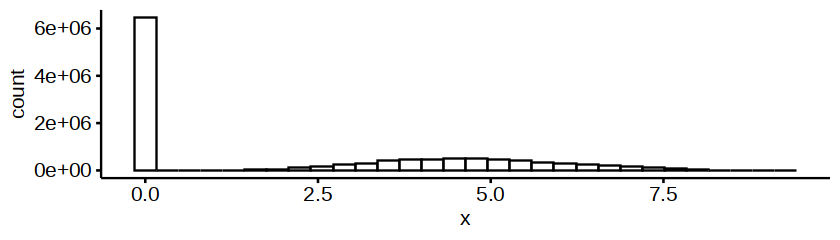

In [45]:
gghistogram(as.vector(lognormalised))

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”
Warning message:
“Removed 2 rows containing missing values (`geom_bar()`).”


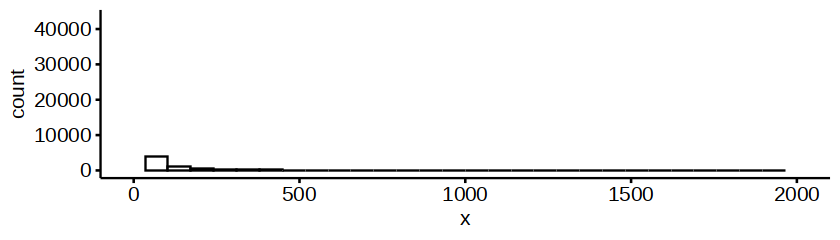

In [46]:
gghistogram(rowVars(Peakmatrix_filt@assays@data$counts)) + xlim(0, 2000)

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


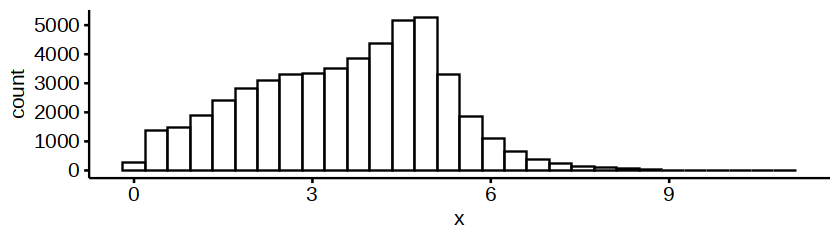

In [47]:
gghistogram(rowVars(lognormalised))

In [48]:
rownames(lognormalised) = rownames(Peakmatrix_filt)

In [136]:
# get peak sets (after reloading notebook)
train_peakset = parse_peaks(train_peaks)
val_peakset = parse_peaks(val_peaks)
test_peakset = parse_peaks(test_peaks)

In [49]:
##################
### Save scores ##
##################
# scores need to be duplicated, since we have positive and negative strand in .fa file
# Train set
train_sequence_activity = round(lognormalised[train_peakset$peak,], 5) # no repping bc only SS instead of including RC
train_sequence_activity_long =  matrix(train_sequence_activity, dimnames=list(t(outer(colnames(train_sequence_activity), rownames(train_sequence_activity), FUN=paste)), NULL))
fwrite(train_sequence_activity_long,  sprintf('%s/train_sequence_activity_log.txt', args$outdir), sep = '\t')

# Validation set
val_sequence_activity = round(lognormalised[val_peakset$peak,], 5)
val_sequence_activity_long =  matrix(val_sequence_activity, dimnames=list(t(outer(colnames(val_sequence_activity), rownames(val_sequence_activity), FUN=paste)), NULL))
fwrite(val_sequence_activity_long,  sprintf('%s/val_sequence_activity_log.txt', args$outdir), sep = '\t', )

# Test set
test_sequence_activity = round(lognormalised[test_peakset$peak,], 5)
test_sequence_activity_long =  matrix(test_sequence_activity, dimnames=list(t(outer(colnames(test_sequence_activity), rownames(test_sequence_activity), FUN=paste)), NULL))
fwrite(test_sequence_activity_long,  sprintf('%s/test_sequence_activity_log.txt', args$outdir), sep = '\t')

x being coerced from class: matrix to data.table

x being coerced from class: matrix to data.table

x being coerced from class: matrix to data.table



## Get TF expression

In [50]:
logcounts = logcounts(tfmatrix_filt)

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


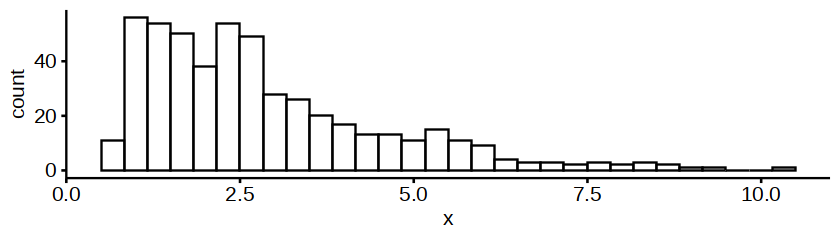

In [51]:
gghistogram(rowVars(logcounts))

In [53]:
get_expr = function(x, peakset){
    tmp = t(logcounts[,x])
    #tmp = tmp[rep(seq_len(nrow(tmp)), each = nrow(peakset)),]
    return(as.data.table(tmp))
}

In [57]:
train_TF_expr = mclapply(colnames(logcounts), get_expr, peakset=train_peakset, mc.cores=14) %>% rbindlist()
fwrite(train_TF_expr,  sprintf('%s/train_TF_expr.txt', args$outdir), sep = '\t', )
val_TF_expr = mclapply(colnames(logcounts), get_expr, peakset=val_peakset, mc.cores=14) %>% rbindlist()
fwrite(val_TF_expr,  sprintf('%s/val_TF_expr.txt', args$outdir), sep = '\t', )
test_TF_expr = mclapply(colnames(logcounts), get_expr, peakset=test_peakset, mc.cores=14) %>% rbindlist()
fwrite(test_TF_expr,  sprintf('%s/test_TF_expr.txt', args$outdir), sep = '\t', )


#### Inspection fastas

In [9]:
################################
### Get Fastas for inspection ##
################################
# prepare fasta file
get_fa_ss = function(x, peakset=train_peaks){ # x=row
    # positive strand
    pos_peak = paste0('>', peakset[x,new_peak], '_+')
    pos_fa = paste(as.character(as.vector(getSeq(Mmusculus, peakset[x,chr],
                                         start=peakset[x,start], end=peakset[x,end]))), collapse="")
    # return
    tmp = c(pos_peak, pos_fa)
    return(tmp)
}

##### Marker peaks from Ricard

In [24]:
marker_peaks = fread(args$markers)

In [25]:
marker_peaks_filt = marker_peaks[celltype %in% args$celltypes] %>% 
    .[order(-logFC)]

In [27]:
get_markers_fa = function(ct, n=200){
    peaks_tmp = parse_peaks(marker_peaks_filt[celltype==ct, feature] %>% head(n))
    fa_tmp = mclapply(1:nrow(peaks_tmp), get_fa_ss, peakset=peaks_tmp, mc.cores=24) %>% unlist()
    writeLines(fa_tmp , sprintf('%s/%s_inspection_markers.fa', args$outdir, ct))    
}

In [29]:
for(i in args$celltypes){
    get_markers_fa(i, n = 200)
}

#### peaks from Luke

In [76]:
get_markers_fa = function(peaks, name, n=2000, cores=24){
    peaks_tmp = parse_peaks(peaks) %>% head(n)
    fa_tmp = mclapply(1:nrow(peaks_tmp), get_fa_ss, peakset=peaks_tmp, mc.cores=cores) %>% unlist()
    fa_tmp = fa_tmp[grep('Error',fa_tmp, invert =T)] # for some reason sometimes throws errors so remove as tmp fix
    writeLines(fa_tmp , sprintf('%s/%s.fa', args$outdir, name))    
}

In [13]:
# SCL in FLK+ cells
SCL_FLK = fread(sprintf('%s/SCL_Flk1+_mm10.bed', args$outdir))

In [77]:
get_markers_fa(SCL_FLK$V4, name='SCL_FLK', n=2000, cores=24) 

Warning message in mclapply(1:nrow(peaks_tmp), get_fa_ss, peakset = peaks_tmp, mc.cores = cores):
“scheduled cores 15, 16, 17, 18, 19 encountered errors in user code, all values of the jobs will be affected”
